In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score, matthews_corrcoef
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


class RobustPeptideFusion(nn.Module):
    def __init__(self, emb_dims, hidden_dim=256, n_heads=4, dropout=0.3):
        super().__init__()
        
        self.keys = sorted(emb_dims.keys()) # Фиксируем порядок модальностей
        self.hidden_dim = hidden_dim
        
        # 1. Проекторы для каждой модальности
        self.projectors = nn.ModuleDict({
            key: nn.Sequential(
                nn.Linear(emb_dims[key], hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.GELU()
            ) for key in self.keys
        })
        
        # 2. Обучаемый запрос (Query) для сбора информации
        self.query_vector = nn.Parameter(torch.randn(1, 1, hidden_dim))
        
        # 3. Attention механизм с поддержкой масок
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim, 
            num_heads=n_heads, 
            batch_first=True,
            dropout=dropout
        )
        
        # 4. Регрессионная голова
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, embeddings_dict):
        """
        embeddings_dict: { 'esm': tensor, 'mtr': tensor, ... }
        Если данных для модальности нет, передавайте тензор нулей.
        """
        batch_size = next(iter(embeddings_dict.values())).size(0)
        device = next(iter(embeddings_dict.values())).device
        
        projected_views = []
        masks = []

        for key in self.keys:
            tensor = embeddings_dict[key]
            
            # Создаем маску: True там, где все значения в строке эмбеддинга — нули (данные отсутствуют)
            # Мы проверяем норму вектора или просто sum. Если 0 — значит данных нет.
            is_missing = (torch.sum(torch.abs(tensor), dim=1) == 0)
            masks.append(is_missing)
            
            # Проектируем (даже если там нули)
            proj = self.projectors[key](tensor)
            projected_views.append(proj)
            
        # Стэкаем эмбеддинги: [Batch, N_views, Hidden]
        stack = torch.stack(projected_views, dim=1)
        
        # Стэкаем маски: [Batch, N_views]
        # В MultiheadAttention True в маске означает "игнорировать этот элемент"
        key_padding_mask = torch.stack(masks, dim=1) 
        
        # ВАЖНО: Если вдруг в строке ВСЕ модальности отсутствуют (бывает при ошибках),
        # заставляем игнорировать всё, кроме первой, чтобы модель не выдала NaN.
        all_missing = key_padding_mask.all(dim=1)
        key_padding_mask[all_missing, 0] = False

        # --- Attention Fusion ---
        query = self.query_vector.repeat(batch_size, 1, 1)
        
        # Мы передаем key_padding_mask, чтобы Attention не смотрел на "нулевые" модальности
        fused_embedding, attn_weights = self.attention(
            query, stack, stack, 
            key_padding_mask=key_padding_mask
        )
        #print(f'fused_emb {fused_embedding.shape}')
        #fused_embedding = fused_embedding.squeeze(1)
        #return self.head(fused_embedding), attn_weights
        return fused_embedding, attn_weights

# --- Использование ---
dims = {'esm': 1280, 'mtr': 1024, 'chemberta': 768}
model = RobustPeptideFusion(dims)
data = {
    'esm': torch.randn(10, 1280),
    'mtr': torch.zeros(10, 1024), # Допустим, MTR данных нет для всего батча
    'chemberta': torch.randn(10, 768)
 }
pred, weights = model(data)

In [2]:
class MultiSpeciesPeptideClassifier(nn.Module):
    def __init__(self, emb_dims, num_species, hidden_dim=256, num_classes=3):
        super().__init__()
        self.fusion_layer = RobustPeptideFusion(emb_dims, hidden_dim) 
        self.species_embedding = nn.Embedding(num_species, 32)
        
        # Теперь выходной слой имеет num_classes (3) нейрона
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.2), # Добавим немного регуляризации
            nn.Linear(128, num_classes)
        )

    def forward(self, embeddings_dict, species_ids):
        fused_chem, attn_weights = self.fusion_layer(embeddings_dict)
        fused_chem = fused_chem.squeeze(1) # [Batch, Hidden]
        
        spec_emb = self.species_embedding(species_ids).squeeze(1) # [Batch, 32]
        
        combined = torch.cat([fused_chem, spec_emb], dim=1)
        logits = self.classifier(combined)
        return logits, attn_weights



In [3]:
import torch
from torch.utils.data import Dataset
import numpy as np

class MultiSpeciesDataset(Dataset):
    def __init__(self, embeddings_dict, species_labels, y_values, task='classification'):
        self.embeddings = embeddings_dict
        self.species = torch.tensor(species_labels, dtype=torch.long)
        self.task = task
        
        if self.task == 'classification':
            # Применяем пороги: <4ч (log 0.602), 4-24ч (log 1.38), >24ч
            self.y = torch.tensor(self._digitize_y(y_values), dtype=torch.long)
        else:
            self.y = torch.tensor(y_values, dtype=torch.float32)

    def _digitize_y(self, y):
        # Логика: 0 - Short, 1 - Moderate, 2 - Long
        return np.where(y < -0.3, 0, np.where(y < 1, 1, 2))

    def __len__(self):
        return len(self.species)

    def __getitem__(self, idx):
        item_embs = {k: v[idx] for k, v in self.embeddings.items()}
        return item_embs, self.species[idx], self.y[idx]

In [4]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def train_classification_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch_embs, org_id, labels in loader:
        batch_embs = {k: v.to(device) for k, v in batch_embs.items()}
        labels = labels.to(device).long() # Метки должны быть Long для CrossEntropy
        org_id = org_id.to(device)

        optimizer.zero_grad()
        logits, _ = model(batch_embs, org_id)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate_classification(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    
    for batch_embs, org_id, labels in loader:
        batch_embs = {k: v.to(device) for k, v in batch_embs.items()}
        org_id = org_id.to(device)
        logits, _ = model(batch_embs, org_id)
        
        preds = torch.argmax(logits, dim=1) # Берем индекс самого вероятного класса
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())
    
    metrics = {
        'Accuracy': accuracy_score(all_targets, all_preds),
        'F1_macro': f1_score(all_targets, all_preds, average='macro'),
        'Report': classification_report(all_targets, all_preds, target_names=['Short', 'Moderate', 'Long'])
    }
    return metrics

In [5]:
# --- Функция загрузки и объединения CSV ---
def load_and_align_data(path_chemberta, path_esm, path_peptmtr, label_col='y', org_col = 'Org_ind'):
    """
    Читает 3 файла, извлекает эмбеддинги и метки.
    Предполагается:
    1. Все колонки, кроме label_col и 'ID', являются измерениями эмбеддинга.
    2. Порядок строк во всех файлах идентичен.
    """
    print(f"Загрузка данных из:\n - {path_chemberta}\n - {path_esm}\n - {path_peptmtr}")
    
    df_chem = pd.read_csv(path_chemberta)
    df_esm = pd.read_csv(path_esm)
    df_mtr = pd.read_csv(path_peptmtr)
    
    # Проверка на совпадение длины
    assert len(df_chem) == len(df_esm) == len(df_mtr), "Ошибка: Файлы имеют разное количество строк!"
    
    # Извлечение меток (берем из первого файла, проверяем совпадение с остальными - хорошая практика)
    y = df_chem[label_col].values
    org_id = df_chem[org_col].values
    
    # Функция для извлечения только колонок с числами (эмбеддингов)
    def get_feats(df):
        # Исключаем метки и ID, если они есть
        cols_to_drop = [c for c in df.columns if c in [label_col, org_col, 'ID', 'id', 'Sequence', 'Smiles', 'Canonical_smiles']]
        return df.drop(columns=cols_to_drop).values.astype(np.float32)

    embeddings = {
        'chemberta': get_feats(df_chem),
        'esm': get_feats(df_esm),
        'mtr': get_feats(df_mtr)
    }
    
    print(f"Загружено {len(y)} образцов.")
    print(f"Размерности: Chem={embeddings['chemberta'].shape}, ESM={embeddings['esm'].shape}, MTR={embeddings['mtr'].shape}")
    
    return embeddings, y, org_id

In [73]:
def plot_results(targets, preds):
    names = ['Short (<4h)', 'Moderate (4-24h)', 'Long (>24h)']
    
    # Печатаем отчет
    print("\\n" + classification_report(targets, preds, target_names=names))
    
    # Строим матрицу
    cm = confusion_matrix(targets, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=names, yticklabels=names)
    plt.title('Normalized Confusion Matrix')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
#import numpy as np

def plot_pretty_confusion_matrix(all_targets, all_preds, labels=['Short', 'Moderate', 'Long']):
    # 1. Считаем матрицу
    cm = confusion_matrix(all_targets, all_preds)
    
    # 2. Считаем проценты для нормализации (по строкам - Recall)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # 3. Настройка графики
    plt.figure(figsize=(10, 8))
    
    # Создаем аннотации: в каждой ячейке будет и число, и процент
    # Например: "15 (75.0%)"
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_percent[i, j]
            if c > 0:
                annot[i, j] = f'{c}\n({p:.1f}%)'
            else:
                annot[i, j] = '0'

    # 4. Визуализация через Seaborn
    sns.heatmap(cm_percent, annot=annot, fmt='', cmap='Blues', 
                xticklabels=labels, yticklabels=labels, annot_kws={'size': 15, 'weight': 'bold'})
    #annot_kws={'size': 25, 'weight': 'bold'}
    plt.tick_params(labelsize = 15)
    plt.title('Confusion Matrix (Counts & Recall %)', fontsize=15)
    plt.ylabel('True Class (Actual)', fontsize=12)
    plt.xlabel('Predicted Class', fontsize=12)
    plt.show()

In [77]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

# 1. Определяем пороги (ТЕ ЖЕ САМЫЕ, что в вашем Dataset!)
# < 4 часов (~0.602) -> Класс 0
# 4-24 часа (~1.380) -> Класс 1
# > 24 часов         -> Класс 2
THRESHOLD_SHORT = -0.3
THRESHOLD_LONG = 1

# 2. Превращаем непрерывный y_train в классы (векторизованно)
# Если y_train это список, сначала сделаем numpy array
y_train_np = np.array(train_y)

conditions = [
    (y_train_np < THRESHOLD_SHORT),
    (y_train_np >= THRESHOLD_SHORT) & (y_train_np < THRESHOLD_LONG),
    (y_train_np >= THRESHOLD_LONG)
]
choices = [0, 1, 2]

# Получаем массив меток [0, 1, 1, 2, 0 ...]
y_train_classes = np.select(conditions, choices, default=1)

# 3. Считаем веса
# 'balanced' автоматически сделает вес = n_samples / (n_classes * np.bincount(y))
class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train_classes), 
    y=y_train_classes
)

# 4. Переводим в тензор и отправляем на GPU
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print(f"Распределение классов в Train: {np.bincount(y_train_classes)}")
print(f"Вычисленные веса: {weights_tensor.cpu().numpy()}")

Распределение классов в Train: [323 369 197]
Вычисленные веса: [0.91744065 0.8030714  1.5042301 ]


In [79]:
BATCH_SIZE = 32
path = 'Data'
#folder = 'Toxicity'
#data_name = 'Tox'

folder = 'Half_life'
data_name = 'Half_life'


emb_name = 'esm2_t12_35M'
# Замените пути на свои реальные файлы
train_embs, train_y, train_org_id = load_and_align_data(f'{path}/{folder}/{data_name}_train_organ_chemberta.csv', f'{path}/{folder}/{data_name}_train_organ_esm2_t33_650M.csv', f'{path}/{folder}/{data_name}_train_organ_pmtr.csv')
#test_embs, test_y, test_org_id = load_and_align_data(f'{path}/{folder}/{data_name}_test_chemberta.csv', f'{path}/{folder}/{data_name}_test_esm2_t33_650M.csv', f'{path}/{folder}/{data_name}_test_pmtr.csv')
test_embs, test_y, test_org_id = load_and_align_data(f'{path}/{folder}/{data_name}_test_inside_chemberta.csv', f'{path}/{folder}/{data_name}_test_inside_esm2_t33_650M.csv', f'{path}/{folder}/{data_name}_test_inside_pmtr.csv')

# Создание DataLoader
train_dataset = MultiSpeciesDataset(train_embs, train_org_id, train_y)
test_dataset = MultiSpeciesDataset(test_embs, test_org_id, test_y)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Инициализация модели, лосса и оптимизатора

# Инициализация
# Параметры
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 500
LR = 1e-6
BATCH_SIZE = 32



# 2. Инициализация модели
emb_dims = {
    'chemberta': train_embs['chemberta'].shape[1],
    'esm': train_embs['esm'].shape[1],
    'mtr': train_embs['mtr'].shape[1]
}
emb_dims_1 = {
    'chemberta': train_embs['chemberta'].shape[1],
    'esm': train_embs['esm'].shape[1]
}

model = MultiSpeciesPeptideClassifier(emb_dims, num_species=5, hidden_dim=256).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1) # Стандарт для классификации
#criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
best_val = 0
patience = 1000
# Обучение
for epoch in range(EPOCHS):
    loss = train_classification_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_metrics = evaluate_classification(model, test_loader, DEVICE)
    
    print(f"Epoch {epoch+1}: Loss: {loss:.4f} | Acc: {val_metrics['Accuracy']:.3f} | F1: {val_metrics['F1_macro']:.3f}")


     # Early Stopping
    if val_metrics['F1_macro'] > best_val:
        best_val = val_metrics['F1_macro']
        torch.save(model.state_dict(), 'best_model.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

# Загрузка лучшей модели для финального теста
model.load_state_dict(torch.load('best_model.pth'))
test_metrics = evaluate_classification(model, test_loader, DEVICE)
print("\nFinal Test Metrics:", test_metrics)

Загрузка данных из:
 - Data/Half_life/Half_life_train_organ_chemberta.csv
 - Data/Half_life/Half_life_train_organ_esm2_t33_650M.csv
 - Data/Half_life/Half_life_train_organ_pmtr.csv
Загружено 889 образцов.
Размерности: Chem=(889, 768), ESM=(889, 1280), MTR=(889, 1024)
Загрузка данных из:
 - Data/Half_life/Half_life_test_inside_chemberta.csv
 - Data/Half_life/Half_life_test_inside_esm2_t33_650M.csv
 - Data/Half_life/Half_life_test_inside_pmtr.csv
Загружено 75 образцов.
Размерности: Chem=(75, 768), ESM=(75, 1280), MTR=(75, 1024)
Epoch 1: Loss: 1.1178 | Acc: 0.360 | F1: 0.176


/home/admingwi/anaconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/admingwi/anaconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/admingwi/anaconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Epoch 2: Loss: 1.1184 | Acc: 0.360 | F1: 0.176
Epoch 3: Loss: 1.1146 | Acc: 0.360 | F1: 0.176


/home/admingwi/anaconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/admingwi/anaconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/admingwi/anaconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Epoch 4: Loss: 1.1161 | Acc: 0.360 | F1: 0.176
Epoch 5: Loss: 1.1156 | Acc: 0.360 | F1: 0.176


...

Epoch 60: Loss: 1.0753 | Acc: 0.373 | F1: 0.299
Epoch 61: Loss: 1.0759 | Acc: 0.373 | F1: 0.299


/home/admingwi/anaconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/admingwi/anaconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/admingwi/anaconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Epoch 62: Loss: 1.0770 | Acc: 0.373 | F1: 0.299
Epoch 63: Loss: 1.0789 | Acc: 0.373 | F1: 0.299


/home/admingwi/anaconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/admingwi/anaconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/admingwi/anaconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Epoch 64: Loss: 1.0750 | Acc: 0.373 | F1: 0.299
Epoch 65: Loss: 1.0762 | Acc: 0.373 | F1: 0.299
Epoch 66: Loss: 1.0753 | Acc: 0.373 | F1: 0.302
Epoch 67: Loss: 1.0698 | Acc: 0.373 | F1: 0.302
Epoch 68: Loss: 1.0749 | Acc: 0.373 | F1: 0.302
Epoch 69: Loss: 1.0759 | Acc: 0.373 | F1: 0.302
Epoch 70: Loss: 1.0704 | Acc: 0.373 | F1: 0.301
Epoch 71: Loss: 1.0718 | Acc: 0.373 | F1: 0.301
Epoch 72: Loss: 1.0712 | Acc: 0.360 | F1: 0.290
Epoch 73: Loss: 1.0728 | Acc: 0.360 | F1: 0.290
Epoch 74: Loss: 1.0735 | Acc: 0.360 | F1: 0.290
Epoch 75: Loss: 1.0691 | Acc: 0.387 | F1: 0.310
Epoch 76: Loss: 1.0691 | Acc: 0.387 | F1: 0.310
Epoch 77: Loss: 1.0659 | Acc: 0.387 | F1: 0.310
Epoch 78: Loss: 1.0718 | Acc: 0.387 | F1: 0.310
Epoch 79: Loss: 1.0691 | Acc: 0.387 | F1: 0.310
Epoch 80: Loss: 1.0649 | Acc: 0.387 | F1: 0.310
Epoch 81: Loss: 1.0700 | Acc: 0.387 | F1: 0.310
Epoch 82: Loss: 1.0671 | Acc: 0.387 | F1: 0.310
Epoch 83: Loss: 1.0665 | Acc: 0.387 | F1: 0.310
Epoch 84: Loss: 1.0712 | Acc: 0.400 | F1

In [194]:
test_metrics

{'Accuracy': 0.5866666666666667,
 'F1_macro': 0.5844081818774022,
 'Report': '              precision    recall  f1-score   support\n\n       Short       0.69      0.72      0.71        25\n    Moderate       0.52      0.56      0.54        27\n        Long       0.55      0.48      0.51        23\n\n    accuracy                           0.59        75\n   macro avg       0.59      0.58      0.58        75\nweighted avg       0.59      0.59      0.59        75\n'}

In [182]:
#torch.save(model.state_dict(), f'Models/{folder}/{data_name}_org_esm_chemb_67.pth')

In [10]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


emb_dims_1 = {
    'chemberta': 768,
    'esm': 1280
}
# 1. Создаем архитектуру модели (она должна быть идентична той, на которой обучались)
model = MultiSpeciesPeptideClassifier(emb_dims_1, num_species=5, hidden_dim=256).to(DEVICE)

# 2. Безопасно загружаем веса
device = torch.device("cuda" + "" if torch.cuda.is_available() else "cpu")
weights = torch.load('Models/Half_life/Half_life_org_esm_chemb__.pth', map_location=device)

model.load_state_dict(weights)
model.to(device)
model.eval()

MultiSpeciesPeptideClassifier(
  (fusion_layer): RobustPeptideFusion(
    (projectors): ModuleDict(
      (chemberta): Sequential(
        (0): Linear(in_features=768, out_features=256, bias=True)
        (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (2): GELU(approximate='none')
      )
      (esm): Sequential(
        (0): Linear(in_features=1280, out_features=256, bias=True)
        (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (2): GELU(approximate='none')
      )
    )
    (attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
    )
    (head): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=1, bias=True)
    )
  )
  (species_embedding): Embedding(5, 32)
  (classifier): Sequential(
    (0): Linear(in_features=288, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout

In [11]:
BATCH_SIZE = 32
path = 'Data'
#folder = 'Toxicity'
#data_name = 'Tox'

folder = 'Half_life'
data_name = 'Half_life'


emb_name = 'esm2_t12_35M'
# Замените пути на свои реальные файлы
#train_embs, train_y, train_org_id = load_and_align_data(f'{path}/{folder}/{data_name}_train_organ_chemberta.csv', f'{path}/{folder}/{data_name}_train_organ_esm2_t33_650M.csv', f'{path}/{folder}/{data_name}_train_organ_pmtr.csv')
test_embs_out, test_y_out, test_org_id_out = load_and_align_data(f'{path}/{folder}/{data_name}_test_chemberta.csv', f'{path}/{folder}/{data_name}_test_esm2_t33_650M.csv', f'{path}/{folder}/{data_name}_test_pmtr.csv')
test_embs, test_y, test_org_id = load_and_align_data(f'{path}/{folder}/{data_name}_test_inside_chemberta.csv', f'{path}/{folder}/{data_name}_test_inside_esm2_t33_650M.csv', f'{path}/{folder}/{data_name}_test_inside_pmtr.csv')

# Создание DataLoader
#train_dataset = MultiSpeciesDataset(train_embs, train_org_id, train_y)
test_out_dataset = MultiSpeciesDataset(test_embs_out, test_org_id_out, test_y_out)
test_dataset = MultiSpeciesDataset(test_embs, test_org_id, test_y)
test_out_dataset = MultiSpeciesDataset(test_embs_out, test_org_id_out, test_y_out)

test_out_loader = DataLoader(test_out_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Загрузка данных из:
 - Data/Half_life/Half_life_test_chemberta.csv
 - Data/Half_life/Half_life_test_esm2_t33_650M.csv
 - Data/Half_life/Half_life_test_pmtr.csv
Загружено 17 образцов.
Размерности: Chem=(17, 768), ESM=(17, 1280), MTR=(17, 1024)
Загрузка данных из:
 - Data/Half_life/Half_life_test_inside_chemberta.csv
 - Data/Half_life/Half_life_test_inside_esm2_t33_650M.csv
 - Data/Half_life/Half_life_test_inside_pmtr.csv
Загружено 75 образцов.
Размерности: Chem=(75, 768), ESM=(75, 1280), MTR=(75, 1024)


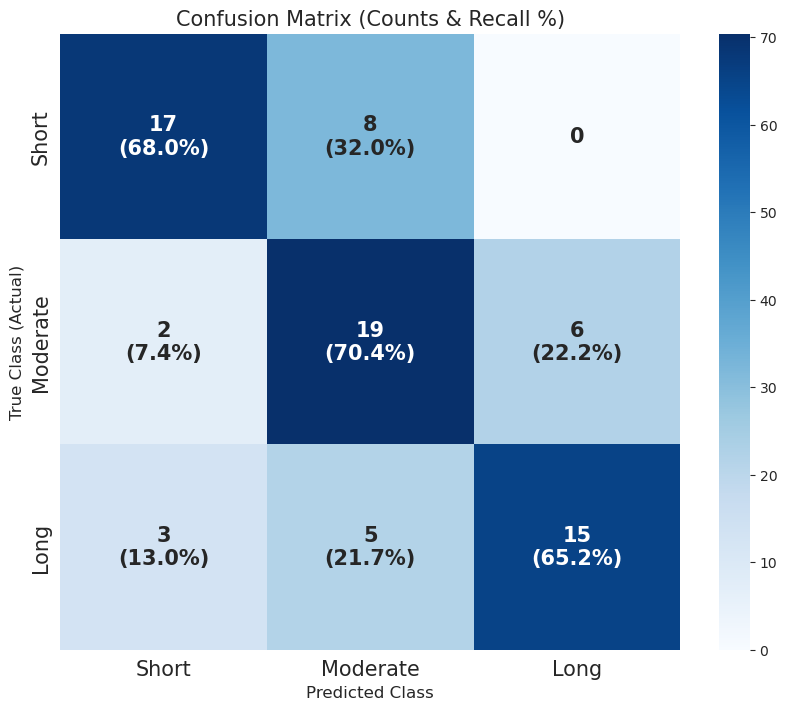

In [74]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    all_logits = []
    for batch_embs, species_ids, labels in loader:
        batch_embs = {k: v.to(device) for k, v in batch_embs.items()}
        species_ids = species_ids.to(device)
        
        # Если модель возвращает (logits, weights), пишем: logits, _ = model(...)
        # Если только logits, то оставляем как ниже:
        output = model(batch_embs, species_ids)
        
        # Проверка на случай, если модель вернула кортеж (logits, attn)
        if isinstance(output, tuple):
            logits = output[0]
        else:
            logits = output
            
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())
        all_logits.extend(logits.cpu().numpy())
        
    return all_targets, all_preds, np.array(all_logits)

    
y_true, y_pred, logits_n = get_predictions(model, test_loader, DEVICE)
plot_pretty_confusion_matrix(y_true, y_pred)


In [54]:
logits_n.shape

(75, 3)

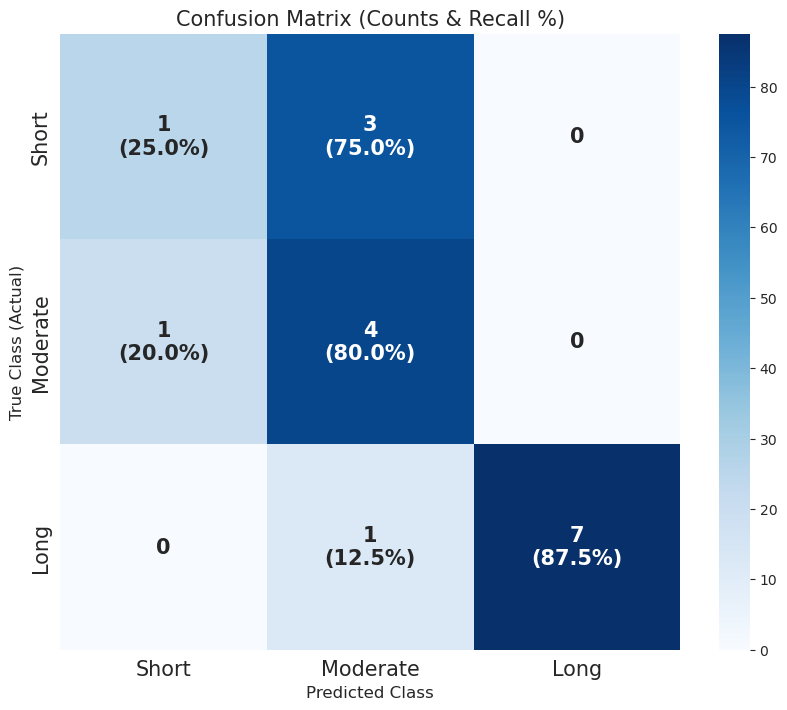

In [75]:
y_true_out, y_pred_out, logits_output = get_predictions(model, test_out_loader, DEVICE)
plot_pretty_confusion_matrix(y_true_out, y_pred_out)

In [57]:

logits_array.shape

(17, 3)

In [67]:
df_out = pd.DataFrame({'True': y_true_out, 'Pred': y_pred_out})
df_out['0 class logit'] = logits_array[:, 0]
df_out['1 class logit'] = logits_array[:, 1]
df_out['2 class logit'] = logits_array[:, 2]
df_out.to_excel(f'Models/Half_life/Half_life_test_out_pred.xlsx', index=None)

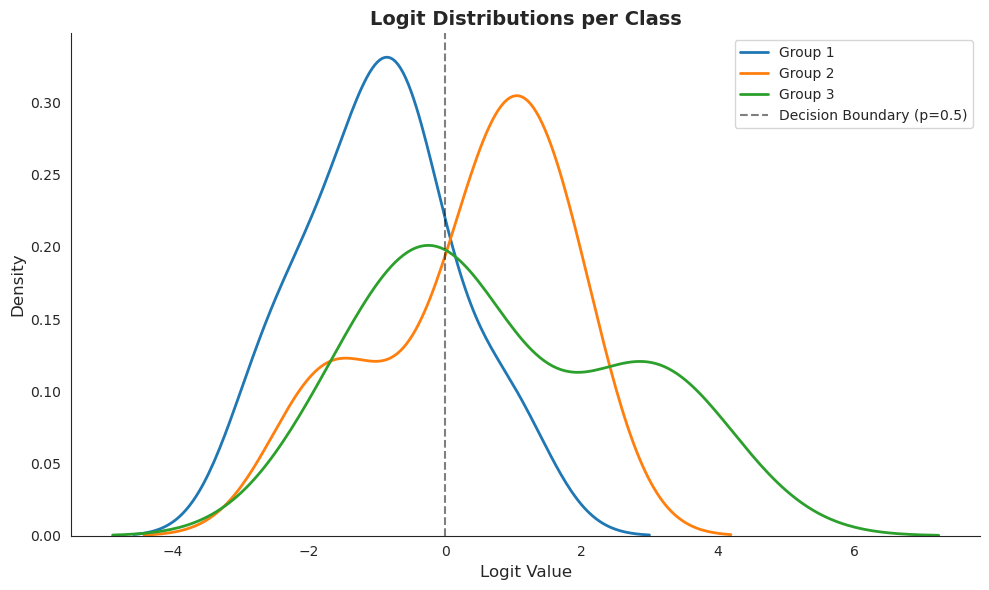

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_logit_distributions(logits_list, labels, title="Logit Distributions per Class"):
    """
    logits_list: список массивов логитов для каждого класса
    labels: названия классов ['Group 1', 'Group 2', 'Group 3']
    """
    plt.figure(figsize=(10, 6))
    sns.set_style("white")
    
    for i, class_logits in enumerate(logits_list):
        sns.kdeplot(class_logits, label=labels[i], linewidth=2)
    
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Decision Boundary (p=0.5)')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Logit Value', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    sns.despine()
    plt.tight_layout()
    plt.savefig("logits_distribution.png", dpi=300)

# Пример использования:
plot_logit_distributions([logits_array[:, 0], logits_array[:, 1], logits_array[:, 2]], ['Group 1', 'Group 2', 'Group 3'])

In [60]:
df_test = pd.DataFrame({'True': y_true, 'Pred': y_pred})
df_test      

,True,Pred
0,1,1
1,2,0
2,0,1
3,2,1
4,1,1
...,...,...
70,0,0
71,0,0
72,0,1
73,0,0


In [66]:
logits_in_array = logits_n
df_in = pd.DataFrame({'True': y_true, 'Pred': y_pred})
df_in['0 class logit'] = logits_in_array[:, 0]
df_in['1 class logit'] = logits_in_array[:, 1]
df_in['2 class logit'] = logits_in_array[:, 2]
df_in.to_excel(f'Models/Half_life/Half_life_test_inside_pred.xlsx', index=None)

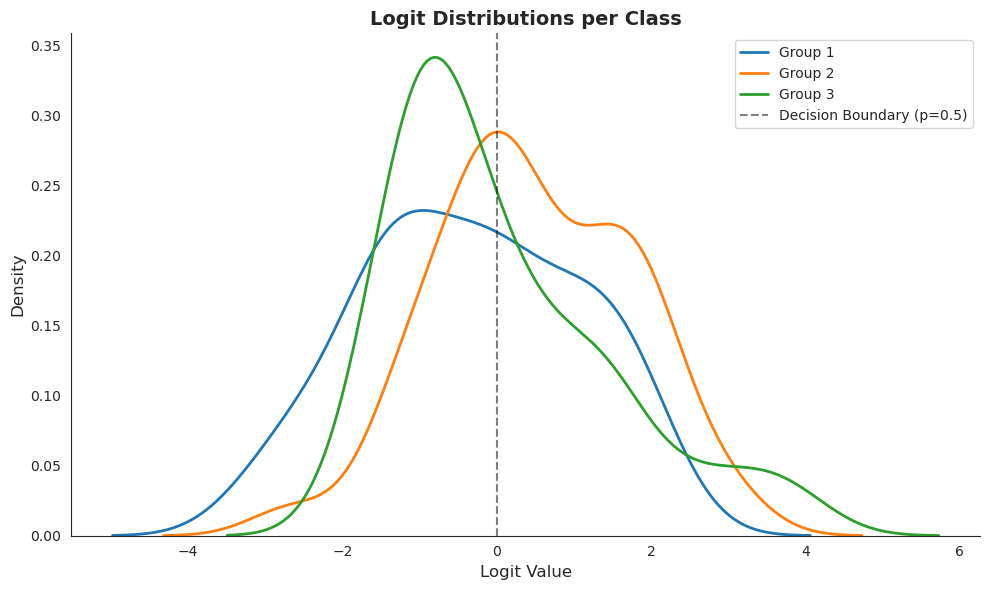

In [63]:
plot_logit_distributions([logits_in_array[:, 0], logits_in_array[:, 1], logits_in_array[:, 2]], ['Group 1', 'Group 2', 'Group 3'])

График важности сохранен как attention_analysis.png

Средние веса внимания:
ChemBERTa     0.260774
ESM-2         0.287332
PeptideMTR    0.451894
dtype: float32


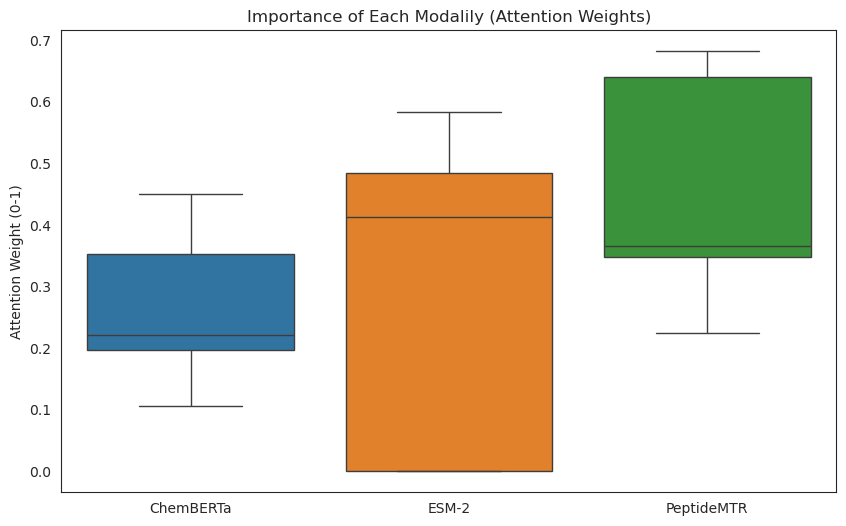

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_attention(model, loader, device):
    model.eval()
    # Список для хранения весов: [Batch, 1, 3] -> [ESM, Chem, MTR]
    # Порядок зависит от keys = sorted(emb_dims.keys()) -> ['chemberta', 'esm', 'peptmtr']
    all_weights = [] 
    
    with torch.no_grad():
        for batch_embs, org_id, labels in loader:
            batch_embs = {k: v.to(device) for k, v in batch_embs.items()}
            org_id = org_id.to(device).view(-1, 1)
            _, weights = model(batch_embs, org_id) 
            # weights shape: [Batch, 1, Src_Len] = [32, 1, 3]
            all_weights.append(weights.cpu().numpy())
            
    # Объединяем в один массив [N_samples, 3]
    all_weights = np.concatenate(all_weights, axis=0).squeeze(1)
    
    # Создаем DataFrame для удобства
    # Важно: проверить порядок ключей в модели! self.keys = sorted(...)
    # Обычно сортировка: ['chemberta', 'esm', 'peptmtr']
    df_att = pd.DataFrame(all_weights, columns=['ChemBERTa', 'ESM-2', 'PeptideMTR'])
    #df_att = pd.DataFrame(all_weights, columns=['ChemBERTa', 'ESM-2'])
    
    return df_att

# 1. Извлекаем веса
att_df = analyze_attention(model, test_out_loader, DEVICE)

# 2. Визуализация (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=att_df)
plt.title("Importance of Each Modalily (Attention Weights)")
plt.ylabel("Attention Weight (0-1)")
plt.savefig("attention_analysis.png", dpi=300)
print("График важности сохранен как attention_analysis.png")

# 3. Текстовый вывод для статьи
print("\nСредние веса внимания:")
print(att_df.mean())


--- Отчет для варианта: ChemBERTa Only ---
              precision    recall  f1-score   support

       Short       0.50      0.25      0.33         4
    Moderate       0.40      0.40      0.40         5
        Long       0.70      0.88      0.78         8

    accuracy                           0.59        17
   macro avg       0.53      0.51      0.50        17
weighted avg       0.56      0.59      0.56        17



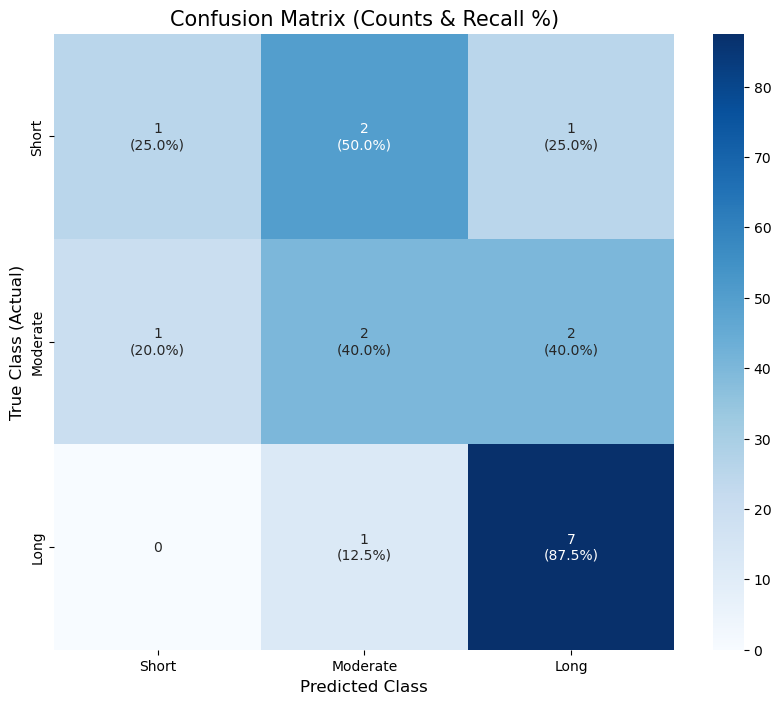


--- Отчет для варианта: ESM-2 Only ---
              precision    recall  f1-score   support

       Short       0.00      0.00      0.00         4
    Moderate       0.50      0.60      0.55         5
        Long       0.50      0.25      0.33         8

    accuracy                           0.29        17
   macro avg       0.33      0.28      0.29        17
weighted avg       0.38      0.29      0.32        17



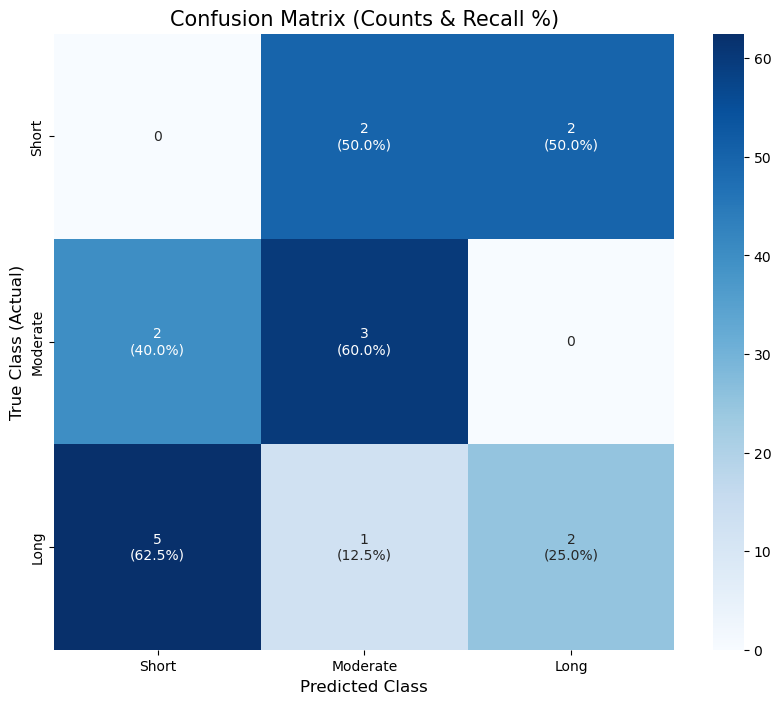


--- Отчет для варианта: ChemBERTa and ESM-2 ---
              precision    recall  f1-score   support

       Short       0.50      0.25      0.33         4
    Moderate       0.50      0.80      0.62         5
        Long       1.00      0.88      0.93         8

    accuracy                           0.71        17
   macro avg       0.67      0.64      0.63        17
weighted avg       0.74      0.71      0.70        17



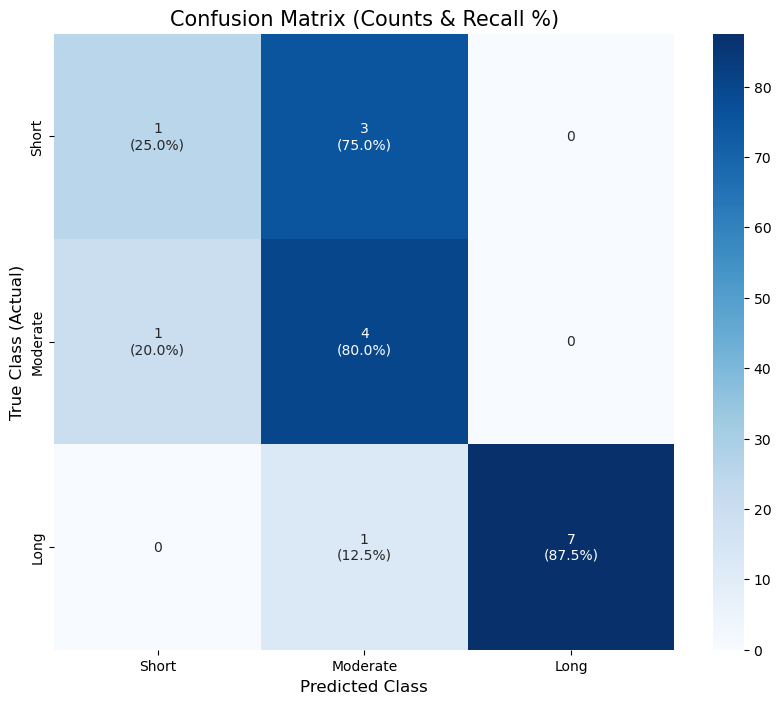


Сводная таблица результатов:
            Variant  Accuracy  F1 (Weighted)  F1 (Macro)  Precision (W)
     ChemBERTa Only  0.588235       0.562092    0.503704       0.564706
         ESM-2 Only  0.294118       0.317291    0.292929       0.382353
ChemBERTa and ESM-2  0.705882       0.698643    0.627350       0.735294


In [19]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, precision_score, classification_report

@torch.no_grad()
def run_ablation_study_classification(model, loader, device, emb_dims):
    model.eval()
    results = []
    
    # Список комбинаций (соответствует вашим ключам в словаре эмбеддингов)
    scenarios = [
        ("ChemBERTa Only", ['chemberta']),
        ("ESM-2 Only", ['esm']),
        ("ChemBERTa and ESM-2", ['chemberta', 'esm'])
    ]
    
    for name, active_keys in scenarios:
        all_preds = []
        all_labels = []
        
        for batch_embs, org_id, labels in loader:
            # Создаем абляционный батч
            ablated_batch = {}
            for k in emb_dims.keys():
                if k in active_keys:
                    ablated_batch[k] = batch_embs[k].to(device)
                else:
                    # Зануляем отсутствующую модальность
                    ablated_batch[k] = torch.zeros_like(batch_embs[k]).to(device)

            org_id = org_id.to(device)
            
            # Получаем логиты. Если модель возвращает (logits, weights), берем только logits
            output = model(ablated_batch, org_id)
            logits = output[0] if isinstance(output, tuple) else output
            
            # Переводим в вероятности (Softmax) и выбираем класс с макс. вероятностью
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        
        # Считаем метрики классификации
        acc = accuracy_score(all_labels, all_preds)
        f1_w = f1_score(all_labels, all_preds, average='weighted')
        f1_m = f1_score(all_labels, all_preds, average='macro')
        prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
        
        results.append({
            "Variant": name,
            "Accuracy": acc,
            "F1 (Weighted)": f1_w,
            "F1 (Macro)": f1_m,
            "Precision (W)": prec
        })
        
        print(f"\n--- Отчет для варианта: {name} ---")
        print(classification_report(all_labels, all_preds, 
                                    target_names=['Short', 'Moderate', 'Long'], 
                                    zero_division=0))
        
        # Вызываем функцию отрисовки матрицы ошибок (из предыдущих шагов)
        plot_pretty_confusion_matrix(all_labels, all_preds, labels=['Short', 'Moderate', 'Long'])
        
    return pd.DataFrame(results)

# Запуск
ablation_results = run_ablation_study_classification(model, test_out_loader, DEVICE, emb_dims_1)
print("\nСводная таблица результатов:")
print(ablation_results.to_string(index=False))


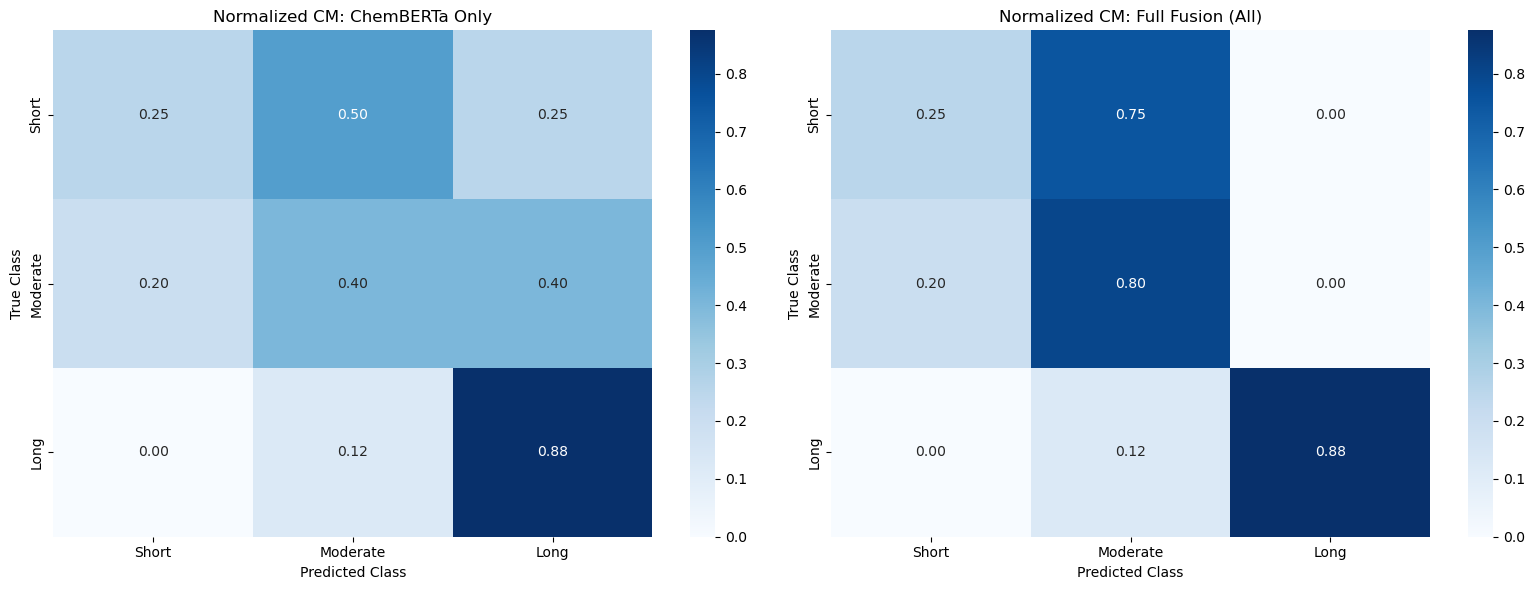

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def compare_ablation_matrices(model, loader, device, emb_dims):
    model.eval()
    scenarios = {
        "ChemBERTa Only": ['chemberta'],
        "Full Fusion (All)": ['chemberta', 'esm']
    }
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    labels = ['Short', 'Moderate', 'Long']
    
    for ax, (name, active_keys) in zip(axes, scenarios.items()):
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch_embs, org_id, labels_batch in loader:
                # Генерируем абляционный батч
                ablated_batch = {}
                for k in emb_dims.keys():
                    if k in active_keys:
                        ablated_batch[k] = batch_embs[k].to(device)
                    else:
                        ablated_batch[k] = torch.zeros_like(batch_embs[k]).to(device)
                
                org_id = org_id.to(device)
                output = model(ablated_batch, org_id)
                logits = output[0] if isinstance(output, tuple) else output
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                
                all_preds.extend(preds)
                all_labels.extend(labels_batch.numpy())
        
        # Считаем и рисуем матрицу
        cm = confusion_matrix(all_labels, all_preds)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                    xticklabels=labels, yticklabels=labels)
        ax.set_title(f'Normalized CM: {name}')
        ax.set_ylabel('True Class')
        ax.set_xlabel('Predicted Class')

    plt.tight_layout()
    plt.show()

# Запуск сравнения
compare_ablation_matrices(model, test_out_loader, DEVICE, emb_dims_1)

In [70]:
cm_norm


NameError: name 'cm_norm' is not defined